<a href="https://colab.research.google.com/github/Himanikumari-ml/online-retail-data-analytics/blob/main/Online-Retail-Data-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Online Retail Data Analysis

## Exploratory Data Analysis (EDA) using Python

### 👩‍💻 Author
**Himani Kumari**

B.Tech Computer Science Engineering Student

---

## 📌 Project Description

# 📌 Project Description

In today's data-driven world, businesses rely on data analytics to make informed decisions. This project performs a comprehensive Exploratory Data Analysis (EDA) on an Online Retail dataset to uncover valuable business insights.

The analysis includes data cleaning, handling missing values, feature engineering, and visualization to understand customer purchasing behavior, sales performance, product demand, and revenue generation. The project identifies top-selling products, analyzes monthly sales trends, evaluates country-wise performance, and highlights key customer segments.

By leveraging Python, Pandas, NumPy, Matplotlib, and Seaborn, this project demonstrates essential data analytics techniques and transforms raw transactional data into meaningful insights that can support business decision-making.

# 🎯 Project Objectives

The main objectives of this project are:

- Perform data cleaning and preprocessing.
- Handle missing values.
- Analyze customer purchasing behavior.
- Identify top-selling products.
- Analyze monthly sales trends.
- Compare sales across different countries.
- Generate business insights using visualizations.

# 📂 Dataset Information

The dataset contains transaction records from an online retail store.

### Features

- Invoice Number
- Stock Code
- Product Description
- Quantity
- Invoice Date
- Unit Price
- Customer ID
- Country

The dataset is used for educational and analytical purposes.

In [ ]:
# ============================================================
# Online Retail Dataset Project
# ============================================================


In [ ]:
# Install/read Excel support
!pip -q install openpyxl

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
# ============================================================
# 1. File Path
# ============================================================

In [ ]:
# Upload the Excel file to Colab first, or keep this upload block.

In [ ]:
FILE_PATH = "/content/onlin retail dataset.xlsx"


In [ ]:
if not os.path.exists(FILE_PATH):
    print("Upload your file: onlin retail dataset.xlsx")
    uploaded = files.upload()
    FILE_PATH = "/content/" + list(uploaded.keys())[0]

Upload your file: onlin retail dataset.xlsx


Saving onlin retail dataset.xlsx to onlin retail dataset.xlsx


In [ ]:
print("Using file:", FILE_PATH)

Using file: /content/onlin retail dataset.xlsx


In [ ]:
# ============================================================
# 2. Load Dataset
# ============================================================

In [ ]:
df = pd.read_excel(FILE_PATH, sheet_name="Online Retail")

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())


Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


None

In [ ]:
# ============================================================
# 3. Data Cleaning
# ============================================================


In [ ]:
df.columns = df.columns.str.strip()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Description"] = df["Description"].fillna("Unknown Product")
df["CustomerID"] = df["CustomerID"].fillna("Unknown")


In [ ]:
 #Remove cancelled/invalid transactions for sales analysis

In [ ]:
df_clean = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
].copy()

df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)
print("Cleaned dataset shape:", df_clean.shape)
display(df_clean.head())




Cleaned dataset shape: (530104, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [ ]:
# Create output folder for charts
OUTPUT_DIR = "/content/online_retail_charts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the structure of the data and discover important patterns before building any predictive models.

In [ ]:
# ============================================================
# Case Study 1: Top Selling Products
# ============================================================

,Description,Quantity
2387,"PAPER CRAFT , LITTLE BIRDIE",80995
2052,MEDIUM CERAMIC TOP STORAGE JAR,78033
3934,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047
1816,JUMBO BAG RED RETROSPOT,48474
3844,WHITE HANGING HEART T-LIGHT HOLDER,37891
2681,POPCORN HOLDER,36761
227,ASSORTED COLOUR BIRD ORNAMENT,36461
2337,PACK OF 72 RETROSPOT CAKE CASES,36419
2741,RABBIT NIGHT LIGHT,30788
2107,MINI PAINT SET VINTAGE,26633


/tmp/ipykernel_6729/87780186.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_products, x="Quantity", y="Description", palette="viridis")


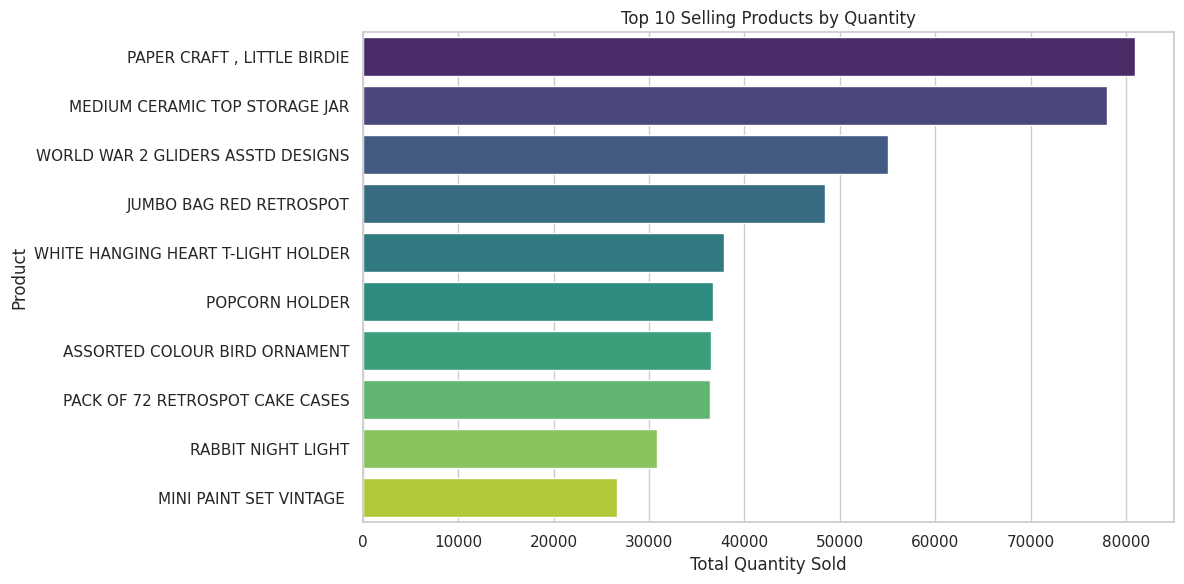

In [ ]:
product_quantity = (
    df_clean.groupby("Description", as_index=False)["Quantity"]
    .sum()
    .sort_values("Quantity", ascending=False)
)

top_10_products = product_quantity.head(10)

display(top_10_products)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_products, x="Quantity", y="Description", palette="viridis")
plt.title("Top 10 Selling Products by Quantity")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/case1_top_selling_products.png", dpi=300)
plt.show()


## 💡 Business Insight

The top-selling products contribute significantly to total sales.

Businesses should:

- Maintain sufficient inventory.
- Promote these products.
- Bundle them with low-selling products.

In [ ]:
# ============================================================
# Case Study 2: Country-wise Sales Analysis
# ============================================================




In [ ]:
country_analysis = (
    df_clean.groupby("Country")
    .agg(
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Sales=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
)

top_country = country_analysis.iloc[0]

display(country_analysis.head(15))
print("Top Country by Sales:", top_country["Country"])
print("Top Country Sales:", round(top_country["Total_Sales"], 2))


,Country,Total_Orders,Total_Sales
36,United Kingdom,18019,9025222.084
24,Netherlands,94,285446.340
10,EIRE,288,283453.960
14,Germany,457,228867.140
13,France,392,209715.110
0,Australia,57,138521.310
31,Spain,90,61577.110
33,Switzerland,54,57089.900
3,Belgium,98,41196.340
32,Sweden,36,38378.330


Top Country by Sales: United Kingdom
Top Country Sales: 9025222.08


In [ ]:
# Chart 1: Orders by Country

/tmp/ipykernel_6729/742426657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_country_orders, x="Total_Orders", y="Country", palette="mako")


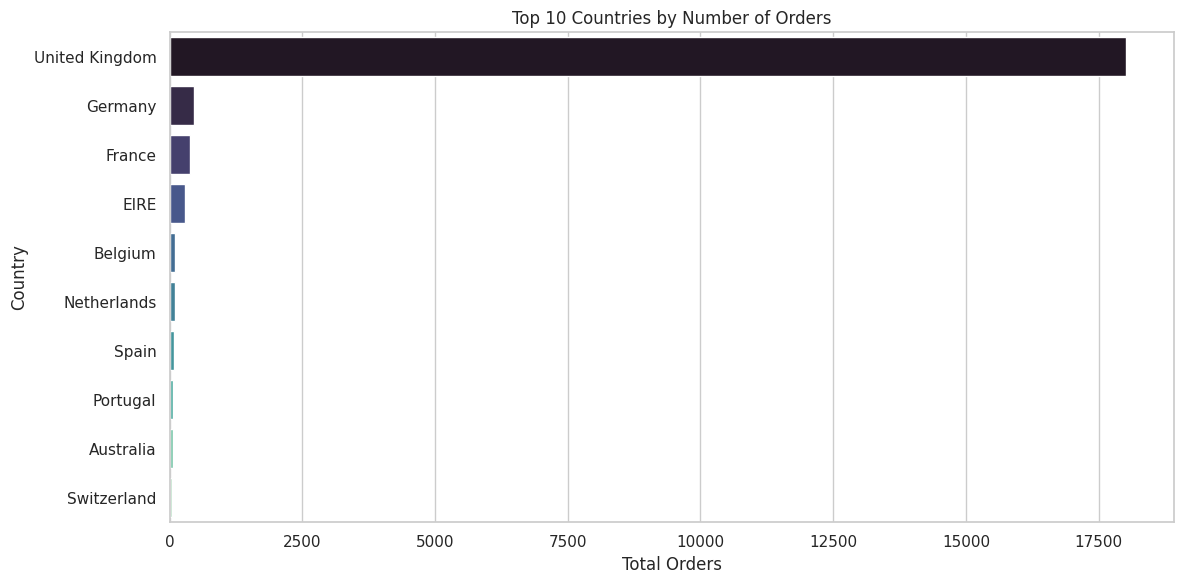

In [ ]:
top_country_orders = country_analysis.sort_values("Total_Orders", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_country_orders, x="Total_Orders", y="Country", palette="mako")
plt.title("Top 10 Countries by Number of Orders")
plt.xlabel("Total Orders")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/case2_country_orders.png", dpi=300)
plt.show()

In [ ]:
# Chart 2: Sales by Country

In [1]:
top_country_sales = country_analysis.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_country_sales, x="Total_Sales", y="Country", palette="crest")
plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/case2_country_sales.png", dpi=300)
plt.show()

NameError: name 'country_analysis' is not defined

## 💡 Business Insight

Some countries generate much higher revenue than others.

This information helps businesses:

- Expand into profitable markets.
- Optimize shipping operations.
- Target country-specific marketing campaigns.

In [ ]:
# ============================================================
# Case Study 3: Monthly Sales Trend
# ============================================================


,Month,Revenue
0,2010-12,823746.140
1,2011-01,691364.560
2,2011-02,523631.890
3,2011-03,717639.360
4,2011-04,537808.621
5,2011-05,770536.020
6,2011-06,761739.900
7,2011-07,719221.191
8,2011-08,759138.380
9,2011-09,1058590.172


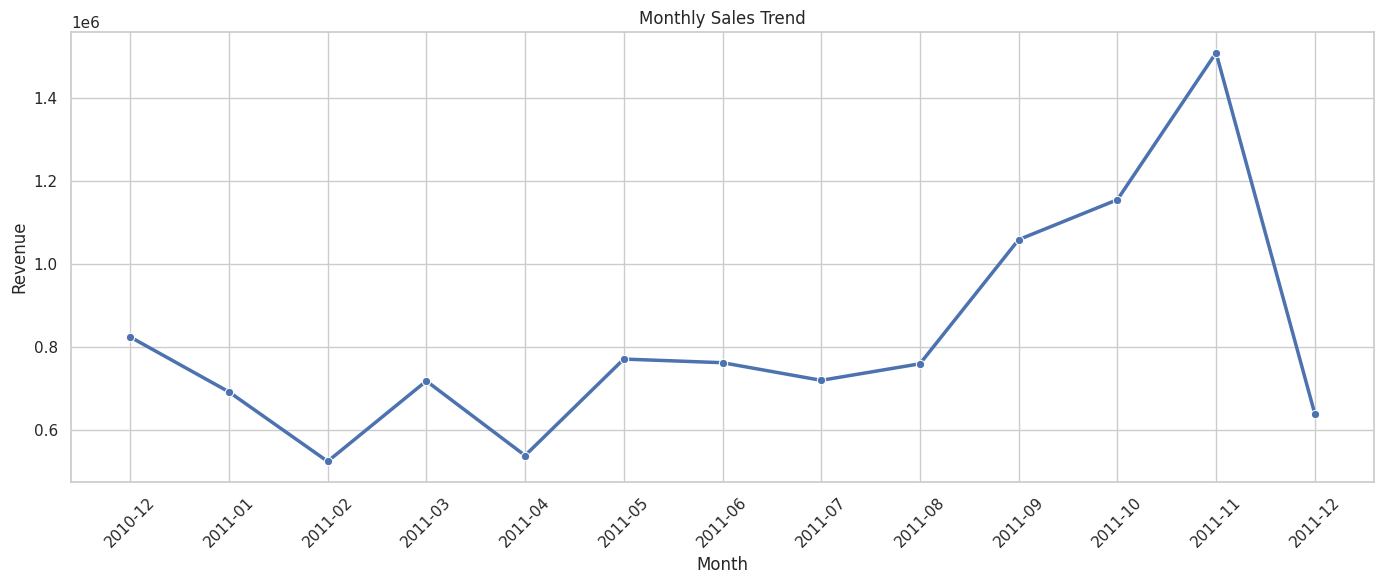

In [ ]:
monthly_sales = (
    df_clean.groupby("Month", as_index=False)["Revenue"]
    .sum()
    .sort_values("Month")
)

display(monthly_sales)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x="Month", y="Revenue", marker="o", linewidth=2.5)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/case3_monthly_sales_trend.png", dpi=300)
plt.show()

## 💡 Business Insight

Monthly sales trends help identify seasonal demand.

Businesses can:

- Increase inventory during peak months.
- Launch marketing campaigns before high-demand periods.
- Plan staffing based on expected sales.

In [ ]:

# ============================================================
# Case Study 4: Customer Purchase Analysis
# ============================================================

,CustomerID,Purchase_Count,Total_Revenue
326,12748.0,209,33719.73
1879,14911.0,201,143825.06
4010,17841.0,124,40991.57
562,13089.0,97,58825.83
1661,14606.0,93,12156.65
2176,15311.0,91,60767.90
481,12971.0,86,11189.91
1689,14646.0,73,280206.02
2702,16029.0,63,81024.84
795,13408.0,62,28117.04


Average Order Value: 534.4


/tmp/ipykernel_6729/4127021772.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


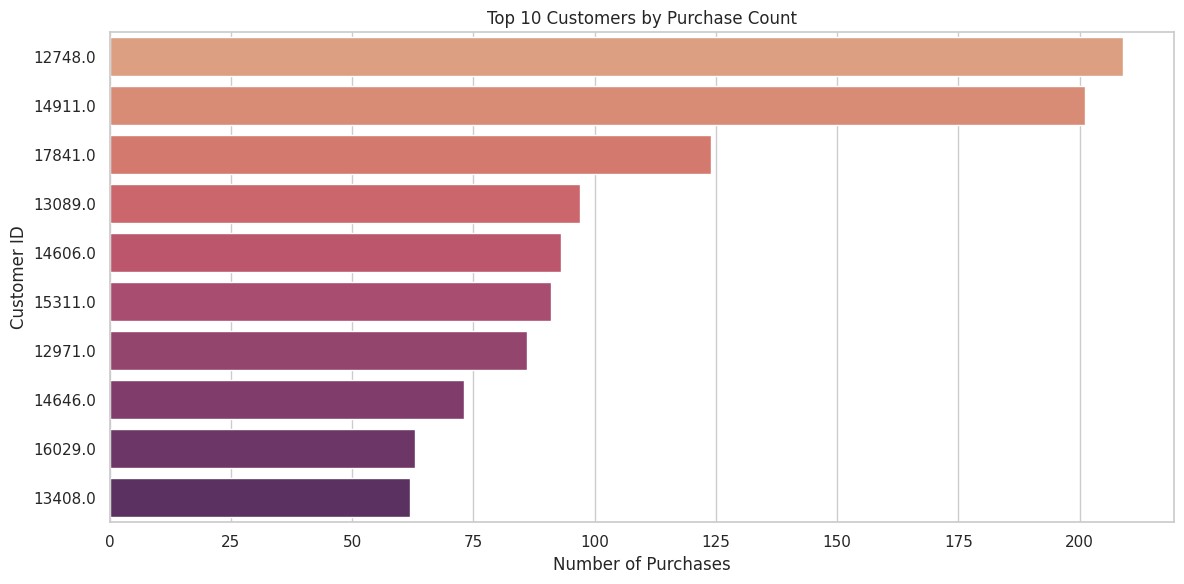

In [ ]:
customer_purchases = (
    df_clean[df_clean["CustomerID"] != "Unknown"]
    .groupby("CustomerID")
    .agg(
        Purchase_Count=("InvoiceNo", "nunique"),
        Total_Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Purchase_Count", ascending=False)
)

top_10_customers = customer_purchases.head(10)

invoice_revenue = (
    df_clean.groupby("InvoiceNo", as_index=False)["Revenue"]
    .sum()
)

average_order_value = invoice_revenue["Revenue"].mean()

display(top_10_customers)
print("Average Order Value:", round(average_order_value, 2))

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_customers,
    x="Purchase_Count",
    y=top_10_customers["CustomerID"].astype(str),
    palette="flare"
)
plt.title("Top 10 Customers by Purchase Count")
plt.xlabel("Number of Purchases")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/case4_top_customers.png", dpi=300)
plt.show()

## 💡 Business Insight

A small group of customers contributes a large portion of total revenue.

Businesses should:

- Reward loyal customers.
- Offer personalized discounts.
- Improve customer retention strategies.

In [ ]:
 #============================================================
# Case Study 5: Revenue Analysis
# ============================================================



In [ ]:
total_revenue = df_clean["Revenue"].sum()

product_revenue = (
    df_clean.groupby("Description", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

highest_revenue_product = product_revenue.iloc[0]

print("Total Revenue:", round(total_revenue, 2))
print("Highest Revenue Product:", highest_revenue_product["Description"])
print("Highest Product Revenue:", round(highest_revenue_product["Revenue"], 2))

display(product_revenue.head(10))


Total Revenue: 10666684.54
Highest Revenue Product: DOTCOM POSTAGE
Highest Product Revenue: 206248.77


,Description,Revenue
1067,DOTCOM POSTAGE,206248.77
2853,REGENCY CAKESTAND 3 TIER,174484.74
2387,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3844,WHITE HANGING HEART T-LIGHT HOLDER,106292.77
2413,PARTY BUNTING,99504.33
1816,JUMBO BAG RED RETROSPOT,94340.05
2052,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
2192,Manual,78112.82
2692,POSTAGE,78101.88
2741,RABBIT NIGHT LIGHT,66964.99


## 💡 Business Insight

Revenue analysis identifies the products generating the highest income.

Businesses can:

- Focus marketing on high-revenue products.
- Improve pricing strategies.
- Increase profitability.

In [ ]:
# ============================================================
# Case Study 6: Product Category Performance
# Product-wise Revenue Chart
# ============================================================

/tmp/ipykernel_6729/1592756622.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_revenue_products, x="Revenue", y="Description", palette="rocket")


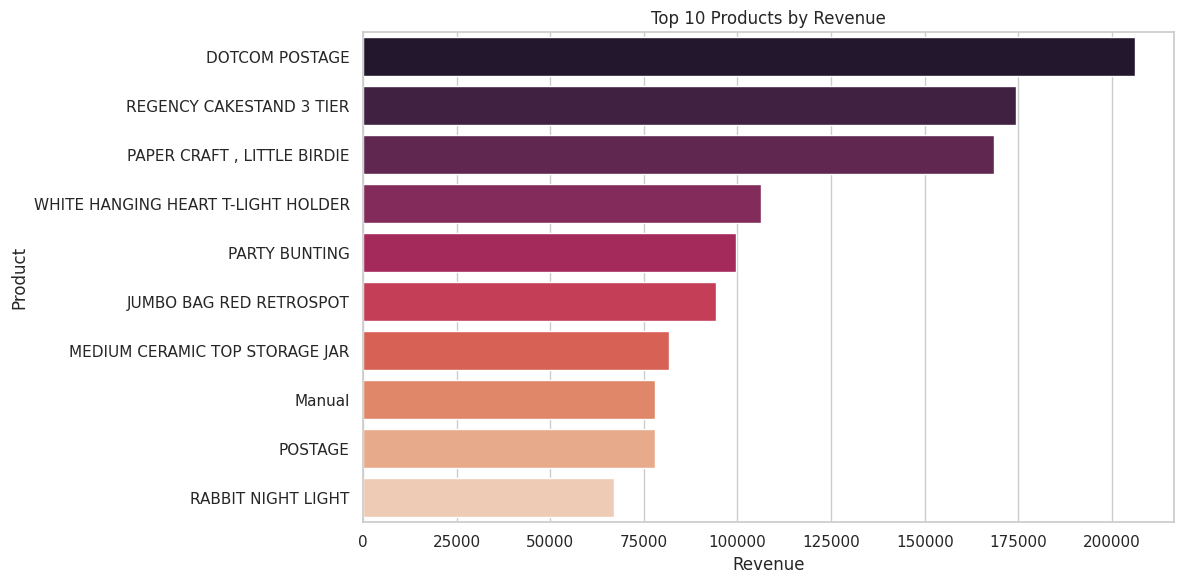

In [ ]:
top_revenue_products = product_revenue.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_revenue_products, x="Revenue", y="Description", palette="rocket")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/case6_product_revenue_chart.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# Case Study 7: Order Quantity Analysis
# ============================================================


Average Quantity Ordered: 10.54
Maximum Quantity Ordered: 80995


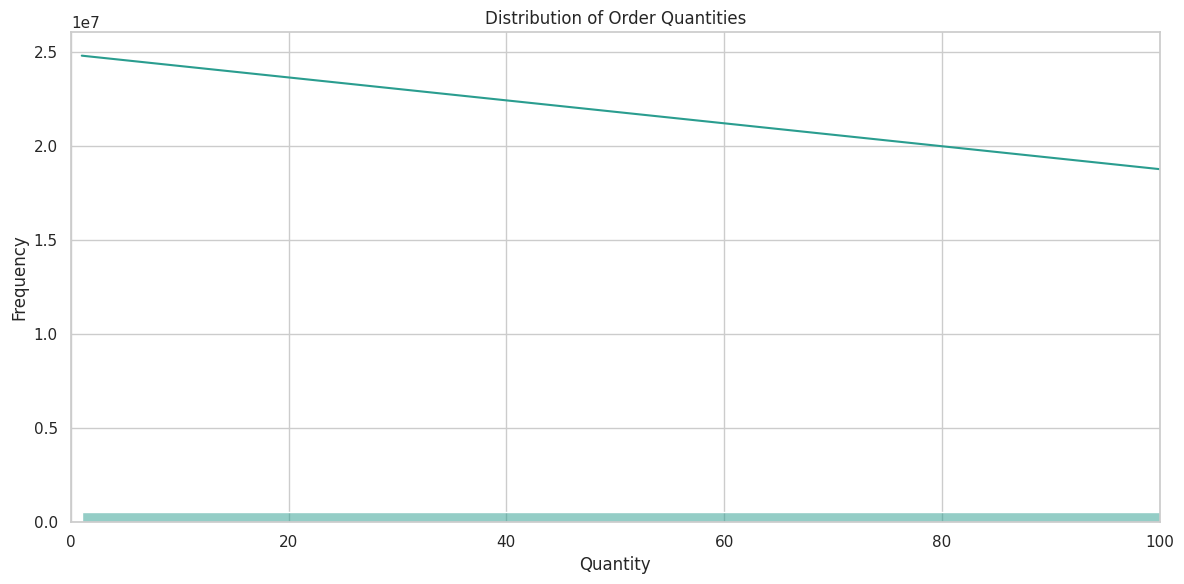

In [ ]:
average_quantity = df_clean["Quantity"].mean()
maximum_quantity = df_clean["Quantity"].max()

print("Average Quantity Ordered:", round(average_quantity, 2))
print("Maximum Quantity Ordered:", maximum_quantity)

plt.figure(figsize=(12, 6))
sns.histplot(df_clean["Quantity"], bins=50, kde=True, color="#2a9d8f")
plt.title("Distribution of Order Quantities")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.xlim(0, df_clean["Quantity"].quantile(0.99))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/case7_quantity_histogram.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# Case Study 8: Sales Dashboard
# ============================================================

In [ ]:
total_orders = df_clean["InvoiceNo"].nunique()
total_customers = df_clean[df_clean["CustomerID"] != "Unknown"]["CustomerID"].nunique()
top_product = product_quantity.iloc[0]["Description"]
top_country_name = country_analysis.iloc[0]["Country"]

print("Dashboard KPIs")
print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Top Product:", top_product)
print("Top Country:", top_country_name)
print("Average Order Value:", round(average_order_value, 2))

fig = plt.figure(figsize=(18, 14))


Dashboard KPIs
Total Revenue: 10666684.54
Total Orders: 19960
Total Customers: 4338
Top Product: PAPER CRAFT , LITTLE BIRDIE
Top Country: United Kingdom
Average Order Value: 534.4


<Figure size 1800x1400 with 0 Axes>

/tmp/ipykernel_6729/1783493662.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_products, x="Quantity", y="Description", ax=ax3, palette="viridis")
/tmp/ipykernel_6729/1783493662.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_country_sales, x="Total_Sales", y="Country", ax=ax4, palette="crest")


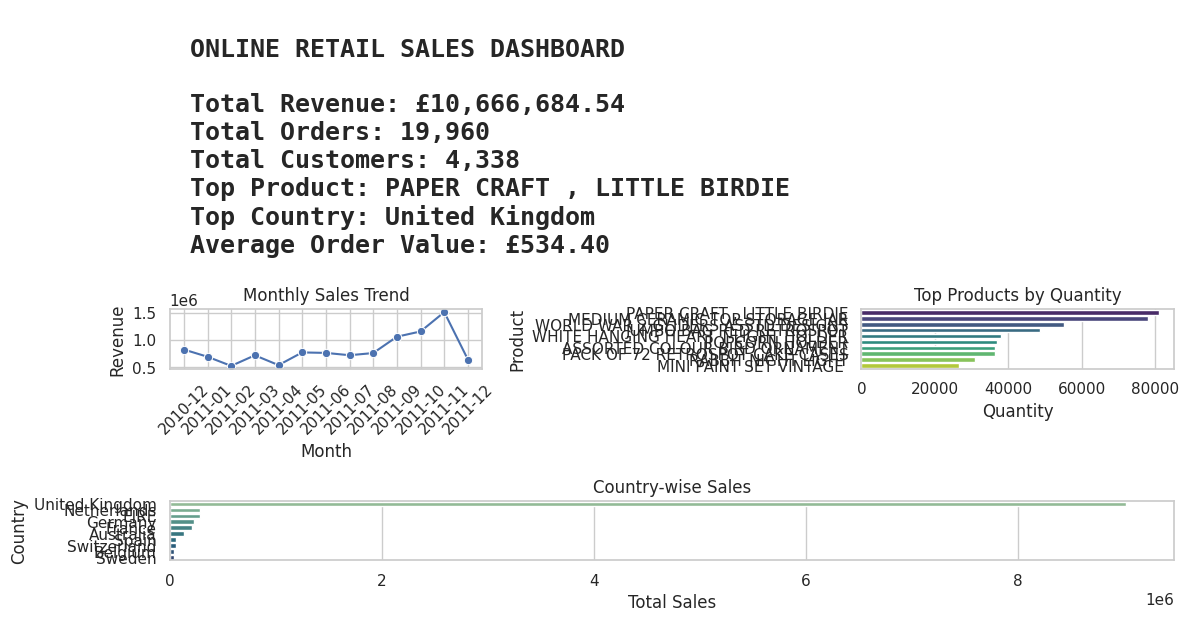

In [ ]:
# KPI text panel
ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2)
ax1.axis("off")

kpi_text = f"""
ONLINE RETAIL SALES DASHBOARD

Total Revenue: £{total_revenue:,.2f}
Total Orders: {total_orders:,}
Total Customers: {total_customers:,}
Top Product: {top_product}
Top Country: {top_country_name}
Average Order Value: £{average_order_value:,.2f}
"""

ax1.text(
    0.02, 0.5, kpi_text,
    fontsize=18,
    fontweight="bold",
    va="center",
    family="monospace"
)

# Monthly sales trend
ax2 = plt.subplot2grid((3, 2), (1, 0))
sns.lineplot(data=monthly_sales, x="Month", y="Revenue", marker="o", ax=ax2)
ax2.set_title("Monthly Sales Trend")
ax2.set_xlabel("Month")
ax2.set_ylabel("Revenue")
ax2.tick_params(axis="x", rotation=45)

# Top products
ax3 = plt.subplot2grid((3, 2), (1, 1))
sns.barplot(data=top_10_products, x="Quantity", y="Description", ax=ax3, palette="viridis")
ax3.set_title("Top Products by Quantity")
ax3.set_xlabel("Quantity")
ax3.set_ylabel("Product")

# Country-wise sales
ax4 = plt.subplot2grid((3, 2), (2, 0), colspan=2)
sns.barplot(data=top_country_sales, x="Total_Sales", y="Country", ax=ax4, palette="crest")
ax4.set_title("Country-wise Sales")
ax4.set_xlabel("Total Sales")
ax4.set_ylabel("Country")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/case8_sales_dashboard.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# Final Summary Tables
# ============================================================


In [ ]:
summary = {
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Top Product",
        "Top Country",
        "Average Order Value",
        "Average Quantity Ordered",
        "Maximum Quantity Ordered"
    ],
    "Value": [
        round(total_revenue, 2),
        total_orders,
        total_customers,
        top_product,
        top_country_name,
        round(average_order_value, 2),
        round(average_quantity, 2),
        maximum_quantity
    ]
}

summary_df = pd.DataFrame(summary)
display(summary_df)

# Save analysis outputs to Excel
OUTPUT_EXCEL = "/content/online_retail_analysis_output.xlsx"

with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="Dashboard KPIs", index=False)
    top_10_products.to_excel(writer, sheet_name="Top Products", index=False)
    country_analysis.to_excel(writer, sheet_name="Country Analysis", index=False)
    monthly_sales.to_excel(writer, sheet_name="Monthly Sales", index=False)
    top_10_customers.to_excel(writer, sheet_name="Top Customers", index=False)
    product_revenue.head(50).to_excel(writer, sheet_name="Product Revenue", index=False)

print("Charts saved in:", OUTPUT_DIR)
print("Excel output saved as:", OUTPUT_EXCEL)

files.download(OUTPUT_EXCEL)

,Metric,Value
0,Total Revenue,10666684.54
1,Total Orders,19960
2,Total Customers,4338
3,Top Product,"PAPER CRAFT , LITTLE BIRDIE"
4,Top Country,United Kingdom
5,Average Order Value,534.4
6,Average Quantity Ordered,10.54
7,Maximum Quantity Ordered,80995


Charts saved in: /content/online_retail_charts
Excel output saved as: /content/online_retail_analysis_output.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ✅ Conclusion

This project successfully analyzed an Online Retail dataset using Python.

Key achievements include:

- Cleaned and prepared the dataset.
- Performed Exploratory Data Analysis.
- Identified top-selling products.
- Analyzed customer purchasing behavior.
- Discovered monthly sales trends.
- Compared country-wise sales.
- Generated valuable business insights using data visualization.

This project demonstrates practical skills in data cleaning, exploratory data analysis, and business intelligence using Python.

# 🚀 Future Improvements

Future enhancements for this project include:

- Sales Forecasting using Machine Learning
- Customer Segmentation
- Recommendation System
- Interactive Dashboard using Power BI
- Tableau Dashboard
- Streamlit Web Application

# 🛠️ Skills Demonstrated

✔ Python

✔ Pandas

✔ NumPy

✔ Matplotlib

✔ Seaborn

✔ Data Cleaning

✔ Exploratory Data Analysis (EDA)

✔ Data Visualization

✔ Business Insights

✔ Statistical Analysis